# Demo 5: Circular Restricted Three-Body Problem (CR3BP) & KAM Torus Theory

In this advanced tutorial, we explore the **Circular Restricted Three-Body Problem (CR3BP)** in the Earth-Moon system using **`bifurx`**, illuminating the deep mathematical connections between Hamiltonian continuation, symplectic Floquet stability, and **Kolmogorov-Arnold-Moser (KAM) Torus Theory** in astrodynamics.

---

### Key Learning Objectives:
1. **Governing Hamiltonian Dynamics**: Formulate the non-dimensional equations of motion in the synodic (rotating) frame and evaluate the conserved **Jacobi integral** $C(x, y, z, \dot{x}, \dot{y}, \dot{z})$.
2. **Collinear Libration Point $L_1$**: Locate the collinear equilibrium $L_1$ and determine its linear spectral structure ($\text{saddle} \times \text{center} \times \text{center}$).
3. **Lyapunov Center Theorem**: Apply Lyapunov's theorem to prove the existence of, and seed, the 1-parameter family of planar periodic orbits born from the in-plane center mode.
4. **Gauss-Legendre Collocation BVP**: Discretize the periodic boundary value problem using 8th-order Gauss-Legendre collocation (`bifurx.bvp.collocation`).
5. **Hamiltonian Pseudo-Arclength Continuation**: Trace the continuous energy-parameterized family of Lyapunov orbits using bordered Newton corrections.
6. **Symplectic Floquet Stability**: Compute the monodromy matrix $M$ via de Boor-Swartz condensation and variational flow (`bifurx.bvp.floquet`), proving symplectic reciprocal pairing ($\lambda, 1/\lambda$) and unit-circle elliptic multipliers ($e^{\pm i \nu}$).
7. **KAM Torus Theory & Spacecraft Missions**:
   - Understand the periodic orbit as an invariant 1-torus $\mathbb{T}^1$.
   - Show how transverse elliptic multipliers span a 2D center manifold $\mathcal{W}^c$, supporting a dense continuum of **2D invariant tori $\mathbb{T}^2$**.
   - Connect KAM persistence of Diophantine tori to real-world **Lissajous orbits** and **quasi-halo orbits**.
   - Discover why flagship space observatories (**JWST**, **SOHO**, **DSCOVR**, **WMAP**) fly on KAM quasi-periodic tori rather than rigid periodic halo orbits, minimizing station-keeping fuel ($\Delta V < 2\text{ m/s/year}$).
   - Discuss resonant tori breakdown (Poincaré-Birkhoff theorem), island chains, Chirikov resonance overlap, and Arnold diffusion in phase space.
8. **Publication-Quality Visualizations**: Render multi-panel orbit families, 3D invariant tori in phase space, characteristic energy-period curves, and complex Floquet multiplier spectra.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

from bifurx.bvp.collocation import (
    CollocationProblem,
    PeriodicOrbitResult,
)
from bifurx.bvp.floquet import compute_floquet_multipliers

# Enable double precision for high-accuracy celestial mechanics and Floquet analysis
jax.config.update("jax_enable_x64", True)

print(f"JAX Version: {jax.__version__}")
print(f"JAX Default Device: {jax.default_backend().upper()}")

JAX Version: 0.11.1
JAX Default Device: CPU


## 1. Governing Equations of the CR3BP & the Jacobi Integral

The Circular Restricted Three-Body Problem models the motion of an infinitesimal mass $m_3$ under the gravitational attraction of two massive primaries $m_1$ and $m_2$ revolving in circular orbits about their common center of mass.

### Non-Dimensional Canonical Units:
- **Total mass**: $M_1 + M_2 = 1$
- **Mass parameter**: $\mu = \dfrac{M_2}{M_1 + M_2} \in (0, 0.5]$ (Earth-Moon: $\mu \approx 0.0121505856$)
- **Primary 1 (Earth)**: mass $1 - \mu$, located at $\mathbf{r}_1 = (-\mu, 0, 0)^T$
- **Primary 2 (Moon)**: mass $\mu$, located at $\mathbf{r}_2 = (1 - \mu, 0, 0)^T$
- **Distance between primaries**: $R = 1$
- **Orbital frequency (mean motion)**: $n = 1$

### Synodic (Rotating) Frame Equations of Motion:
$$\begin{cases}
\ddot{x} - 2\dot{y} = \dfrac{\partial \Omega}{\partial x} \\[1ex]
\ddot{y} + 2\dot{x} = \dfrac{\partial \Omega}{\partial y} \\[1ex]
\ddot{z} = \dfrac{\partial \Omega}{\partial z}
\end{cases}$$

where $\Omega(x, y, z)$ is the **effective potential** combining gravitational and centrifugal potentials:
$$\Omega(x, y, z) = \frac{1}{2}(x^2 + y^2) + \frac{1 - \mu}{d_1} + \frac{\mu}{d_2}$$
with distances $d_1 = \sqrt{(x + \mu)^2 + y^2 + z^2}$ and $d_2 = \sqrt{(x - 1 + \mu)^2 + y^2 + z^2}$.

### The Conserved Jacobi Integral:
Because the Lagrangian is autonomous in the rotating frame, the system possesses a first integral of motion—the **Jacobi constant** $C$:
$$C(x, y, z, \dot{x}, \dot{y}, \dot{z}) = 2\Omega(x, y, z) - (\dot{x}^2 + \dot{y}^2 + \dot{z}^2)$$

For any physical motion, kinetic energy is non-negative ($v^2 \ge 0$), restricting trajectories to regions where $2\Omega(x, y, z) \ge C$. The boundary $2\Omega = C$ forms the **Zero-Velocity Curves (ZVC)**.

In [2]:
# Earth-Moon mass parameter
MU = 0.012150585609624


@jax.jit
def cr3bp_equations(state: jnp.ndarray, p: float = MU) -> jnp.ndarray:
    """CR3BP first-order equations of motion in synodic frame.

    state: [x, y, z, vx, vy, vz]
    returns: [vx, vy, vz, ax, ay, az]
    """
    x, y, z, vx, vy, vz = state[0], state[1], state[2], state[3], state[4], state[5]
    mu = p

    # Distances to Primary 1 and Primary 2
    d1 = jnp.sqrt((x + mu) ** 2 + y**2 + z**2)
    d2 = jnp.sqrt((x - 1.0 + mu) ** 2 + y**2 + z**2)

    d1_3 = d1**3
    d2_3 = d2**3

    # Synodic accelerations with Coriolis and centrifugal terms
    ax = 2.0 * vy + x - (1.0 - mu) * (x + mu) / d1_3 - mu * (x - 1.0 + mu) / d2_3
    ay = -2.0 * vx + y - (1.0 - mu) * y / d1_3 - mu * y / d2_3
    az = -(1.0 - mu) * z / d1_3 - mu * z / d2_3

    return jnp.array([vx, vy, vz, ax, ay, az])


@jax.jit
def jacobi_constant(state: jnp.ndarray, p: float = MU) -> float:
    """Compute the conserved Jacobi integral C."""
    x, y, z, vx, vy, vz = state[0], state[1], state[2], state[3], state[4], state[5]
    mu = p

    d1 = jnp.sqrt((x + mu) ** 2 + y**2 + z**2)
    d2 = jnp.sqrt((x - 1.0 + mu) ** 2 + y**2 + z**2)
    v2 = vx**2 + vy**2 + vz**2

    omega = 0.5 * (x**2 + y**2) + (1.0 - mu) / d1 + mu / d2
    return 2.0 * omega - v2


# Test evaluation
state_test = jnp.array([0.8, 0.0, 0.0, 0.0, 0.1, 0.0])
print(f"Vector field f(state_test) = {cr3bp_equations(state_test)}")
print(f"Jacobi constant C(state_test) = {jacobi_constant(state_test):.6f}")

Vector field f(state_test) = [ 0.          0.1         0.         -0.15334304  0.         -0.        ]
Jacobi constant C(state_test) = 3.192041


## 2. Collinear Lagrange Point $L_1$ & Linear Stability

Equilibrium points (libration points) satisfy $\nabla \Omega = \mathbf{0}$ and $\mathbf{v} = \mathbf{0}$.
The collinear Lagrange point $L_1$ lies on the $x$-axis between the Earth and Moon ($-\mu < x_{L1} < 1 - \mu$).

Setting $y = z = 0$, $x_{L1}$ is the unique zero of the 1D function:
$$f_{L1}(x) = x - \frac{1 - \mu}{(x + \mu)^2} + \frac{\mu}{(1 - \mu - x)^2} = 0$$

### Linearization & Spectral Decomposition:
Let $\delta \mathbf{u} = \mathbf{u} - \mathbf{u}_{L1}$. The Jacobian matrix $A = \nabla \mathbf{f}(L_1)$ decouples into planar and vertical subsystems:
$$\det(\lambda I - A) = \underbrace{(\lambda^2 - U_{zz})}_{\text{out-of-plane}} \cdot \underbrace{(\lambda^4 + (4 - U_{xx} - U_{yy})\lambda^2 + U_{xx}U_{yy})}_{\text{in-plane}} = 0$$

where $U_{xx} > 0$, $U_{yy} < 0$, and $U_{zz} < 0$ are the diagonal entries of the effective potential Hessian $\nabla^2 \Omega(L_1)$.

This yields three fundamental eigenvalue pairs:
1. **Hyperbolic Saddle Pair**: $\lambda_{1, 2} = \pm \lambda_u$ (real, $\lambda_u > 0$), spanning the 1D unstable and 1D stable manifolds $W^u, W^s$.
2. **Planar Center Pair**: $\lambda_{3, 4} = \pm i \omega_p$ (pure imaginary), spanning the 2D in-plane center manifold with period $T_p = 2\pi / \omega_p$.
3. **Vertical Center Pair**: $\lambda_{5, 6} = \pm i \omega_z$ (pure imaginary), spanning the 2D out-of-plane center manifold with period $T_z = 2\pi / \omega_z$.

In [3]:
def locate_l1(mu: float = MU) -> float:
    """Find the L1 libration point between -mu and 1 - mu via 1D root-finding."""

    def f_x(x):
        d1 = x + mu
        d2 = 1.0 - mu - x
        return x - (1.0 - mu) / d1**2 + mu / d2**2

    return brentq(f_x, -mu + 1e-4, 1.0 - mu - 1e-4)


x_l1 = locate_l1(MU)
state_l1 = np.array([x_l1, 0.0, 0.0, 0.0, 0.0, 0.0])
c_l1 = float(jacobi_constant(jnp.array(state_l1)))

# Compute Jacobian via JAX automatic differentiation
jac_fn = jax.jacobian(lambda u: cr3bp_equations(u, MU))
J_l1 = np.array(jac_fn(jnp.array(state_l1)))
eigs, vecs = np.linalg.eig(J_l1)

print("=" * 68)
print(f"Earth-Moon L1 Libration Point: x = {x_l1:.8f}, y = 0.0, z = 0.0")
print(f"L1 Jacobi Constant C_L1       : {c_l1:.8f}")
print("=" * 68)
print("Eigenvalue Spectrum of A = J(L1):")

# Classify eigenvalues
for i, val in enumerate(eigs):
    if abs(val.imag) < 1e-5:
        mode = "Hyperbolic Saddle (Unstable/Stable)"
    elif abs(vecs[1, i]) > 1e-3:
        mode = "Planar Center Mode (In-plane)"
    else:
        mode = "Vertical Center Mode (Out-of-plane)"
    print(f"  lambda_{i + 1} = {val.real:+.6f} + {val.imag:+.6f}i  -->  {mode}")

# Identify planar mode
in_plane_idx = [i for i, val in enumerate(eigs) if abs(val.real) < 1e-5 and abs(vecs[1, i]) > 1e-3][
    0
]
omega_p = abs(eigs[in_plane_idx].imag)
T0 = 2.0 * np.pi / omega_p

# Identify vertical mode
vertical_idx = [i for i, val in enumerate(eigs) if abs(val.real) < 1e-5 and abs(vecs[2, i]) > 1e-3][
    0
]
omega_z = abs(eigs[vertical_idx].imag)
T_z = 2.0 * np.pi / omega_z

print("-" * 68)
print(f"Planar center frequency omega_p = {omega_p:.6f} rad/TU  -->  Period T0  = {T0:.6f} TU")
print(f"Vertical center frequency omega_z = {omega_z:.6f} rad/TU  -->  Period T_z = {T_z:.6f} TU")
print(f"Frequency ratio omega_p / omega_z = {omega_p / omega_z:.6f} (Non-resonant irrational)")
print("=" * 68)

Earth-Moon L1 Libration Point: x = 0.83691513, y = 0.0, z = 0.0
L1 Jacobi Constant C_L1       : 3.18834112
Eigenvalue Spectrum of A = J(L1):
  lambda_1 = -2.932056 + +0.000000i  -->  Hyperbolic Saddle (Unstable/Stable)
  lambda_2 = +2.932056 + +0.000000i  -->  Hyperbolic Saddle (Unstable/Stable)
  lambda_3 = -0.000000 + +2.334386i  -->  Planar Center Mode (In-plane)
  lambda_4 = -0.000000 + -2.334386i  -->  Planar Center Mode (In-plane)
  lambda_5 = +0.000000 + +2.268831i  -->  Vertical Center Mode (Out-of-plane)
  lambda_6 = +0.000000 + -2.268831i  -->  Vertical Center Mode (Out-of-plane)
--------------------------------------------------------------------
Planar center frequency omega_p = 2.334386 rad/TU  -->  Period T0  = 2.691580 TU
Vertical center frequency omega_z = 2.268831 rad/TU  -->  Period T_z = 2.769349 TU
Frequency ratio omega_p / omega_z = 1.028894 (Non-resonant irrational)


## 3. The Lyapunov Center Theorem & Initial Periodic Orbit

Can the linear harmonic oscillation $\pm i \omega_p$ be continued into the fully nonlinear regime?

### Theorem (Lyapunov Center Theorem, 1892; Moser, 1958)
Let $\mathbf{x}^*$ be an equilibrium point of an autonomous real-analytic Hamiltonian system. If the Jacobian matrix has a pair of pure imaginary eigenvalues $\pm i \omega_0$ such that:
$$\frac{\lambda_k}{\pm i \omega_0} \notin \mathbb{Z} \setminus \{-1, 1\} \quad \text{for all other eigenvalues } \lambda_k$$
then there exists an analytic **1-parameter continuous family of periodic orbits** emanating from $\mathbf{x}^*$. The family is parameterized by energy $C$ (or amplitude $\varepsilon$), and as amplitude $\varepsilon \to 0$, the orbital period approaches the linear harmonic period:
$$\lim_{\varepsilon \to 0} T(\varepsilon) = \frac{2\pi}{\omega_0}$$

### Initial Orbit Seeding:
Since $\omega_p / \omega_z \approx 1.0289 \notin \mathbb{Z}$, the non-resonance condition holds. We seed the initial periodic orbit by taking a small perturbation along the planar center eigenvector $\mathbf{v} = \mathbf{v}_r + i \mathbf{v}_i$:
$$\mathbf{u}(\tau) = \mathbf{u}_{L1} + \varepsilon \left( \mathbf{v}_r \cos(2\pi \tau) - \mathbf{v}_i \sin(2\pi \tau) \right), \quad \tau \in [0, 1]$$

In [4]:
# Extract planar center eigenvector
v_planar = vecs[:, in_plane_idx]
v_r = np.real(v_planar)
v_i = np.imag(v_planar)
norm_v = np.sqrt(np.dot(v_r, v_r) + np.dot(v_i, v_i))
v_r /= norm_v
v_i /= norm_v

# Discretize on Gauss-Legendre collocation mesh (N=25 intervals, m=4 Gauss nodes)
N_mesh = 25
m_gauss = 4
dim = 6
prob = CollocationProblem(cr3bp_equations, dim=dim, num_intervals=N_mesh, num_gauss_points=m_gauss)
mesh = jnp.linspace(0.0, 1.0, N_mesh + 1)
rho = np.asarray(prob.rho)

eps_init = 0.005  # small amplitude perturbation
u_mesh_init = np.zeros((N_mesh, dim))
u_gauss_init = np.zeros((N_mesh, m_gauss, dim))

for k in range(N_mesh):
    t_k = float(mesh[k])
    theta_k = 2.0 * np.pi * t_k
    u_mesh_init[k] = state_l1 + eps_init * (v_r * np.cos(theta_k) - v_i * np.sin(theta_k))
    hk = float(mesh[k + 1] - mesh[k])
    for i in range(m_gauss):
        t_g = t_k + hk * rho[i]
        theta_g = 2.0 * np.pi * t_g
        u_gauss_init[k, i] = state_l1 + eps_init * (v_r * np.cos(theta_g) - v_i * np.sin(theta_g))

u_mesh_init = jnp.asarray(u_mesh_init)
u_gauss_init = jnp.asarray(u_gauss_init)
X_init = prob.pack_vars(u_mesh_init, u_gauss_init, T0)

# Polish the initial linear guess with an amplitude-pinning constraint
target_x = float(state_l1[0] + eps_init * v_r[0])
X_cur = np.copy(np.array(X_init))

print("[Newton Solver] Polishing initial Lyapunov orbit from linear center mode...")
for it in range(1, 10):
    res_bvp = np.array(prob.eval_residual(jnp.array(X_cur), MU, mesh, u_mesh_init, u_gauss_init))
    c_res = float(X_cur[0] - target_x)
    G = np.concatenate([res_bvp, [c_res]])
    res_norm = np.linalg.norm(G)
    print(f"  Iteration {it}: Residual Norm = {res_norm:.4e}")
    if res_norm < 1e-8:
        print(f"  --> Converged in {it} iterations! Period T = {X_cur[-1]:.6f}")
        break

    J_bvp = np.array(prob.eval_jacobian(jnp.array(X_cur), MU, mesh, u_mesh_init, u_gauss_init))
    c_row = np.zeros((1, len(X_cur)))
    c_row[0, 0] = 1.0
    J_aug = np.vstack([J_bvp, c_row])
    dX = -np.linalg.lstsq(J_aug, G, rcond=None)[0]
    X_cur += dX

u_m_sol, u_g_sol, T_sol = prob.unpack_vars(jnp.array(X_cur))
sol_init = PeriodicOrbitResult(
    mesh=mesh,
    u_mesh=u_m_sol,
    u_gauss=u_g_sol,
    period=float(T_sol),
    converged=True,
    iterations=it,
    residual_norm=float(res_norm),
    problem=prob,
)

[Newton Solver] Polishing initial Lyapunov orbit from linear center mode...
  Iteration 1: Residual Norm = 1.9357e-03


  Iteration 2: Residual Norm = 9.1013e-08
  Iteration 3: Residual Norm = 1.9900e-13
  --> Converged in 3 iterations! Period T = 2.691638


## 4. Hamiltonian Pseudo-Arclength Continuation

In dissipative dynamical systems with an external continuation parameter $p$, limit cycles are typically isolated for each fixed $p$.

In **autonomous Hamiltonian systems**, however:
- The mass ratio $\mu$ is fixed, yet periodic orbits form an **unbroken 1-parameter continuous family** parameterized by energy (Jacobi constant $C$) or period $T$.
- Consequently, the square collocation BVP Jacobian $\nabla_{\mathbf{X}} \mathbf{R}$ has a **1-dimensional kernel** along the family tangent vector $\boldsymbol{	au}$:
$$\ker \left( \nabla_{\mathbf{X}} \mathbf{R} \right) = \operatorname{span}(\boldsymbol{	au})$$

### Pseudo-Arclength Continuation on the $(\mathbf{u}, T)$ Manifold:
To trace this continuous family, we apply Keller pseudo-arclength continuation directly on the solution manifold $\mathbf{X} = (\mathbf{u}_{\text{mesh}}, \mathbf{u}_{\text{gauss}}, T) \in \mathbb{R}^{D}$:
1. **Predictor**: Advance by step size $\Delta s$ along the unit tangent $\boldsymbol{	au}_k$:
   $$\mathbf{X}^{(0)} = \mathbf{X}_k + \Delta s \boldsymbol{	au}_k$$
2. **Corrector**: Solve the bordered system via least-squares Newton:
   $$\begin{pmatrix} \mathbf{R}(\mathbf{X}) \\[1ex] \boldsymbol{	au}_k^T (\mathbf{X} - \mathbf{X}_k) - \Delta s \end{pmatrix} = \mathbf{0}$$

In [5]:
# Compute initial tangent via SVD of the collocation Jacobian
J_bvp_init = np.array(prob.eval_jacobian(jnp.array(X_cur), MU, mesh, u_m_sol, u_g_sol))
_, _, vh = np.linalg.svd(J_bvp_init)
tau = vh[-1, :]
# Orient tangent in direction of expanding amplitude (decreasing x_min)
if tau[0] > 0:
    tau = -tau
tau /= np.linalg.norm(tau)

family = {
    "T": [],
    "C": [],
    "x_min": [],
    "x_max": [],
    "y_max": [],
    "orbits": [],
    "results": [],
    "multipliers": [],
}

ds = 0.02
max_steps = 25
print(f"Tracing Planar L1 Lyapunov Family ({max_steps} continuation steps)...")
print("-" * 88)
print(
    f"{'Step':>4} | {'Period T':>10} | {'Jacobi C':>10} | {'x_range':>18} | {'y_max':>8} | {'Elliptic Multipliers':>24}"
)
print("-" * 88)

for step in range(max_steps):
    u_m, u_g, T_val = prob.unpack_vars(jnp.array(X_cur))
    C_val = float(jacobi_constant(u_m[0]))

    sol_k = PeriodicOrbitResult(
        mesh=mesh,
        u_mesh=u_m,
        u_gauss=u_g,
        period=float(T_val),
        converged=True,
        iterations=0,
        residual_norm=0.0,
        problem=prob,
    )

    mults, _ = compute_floquet_multipliers(sol_k, p=MU, method="condensation")

    family["T"].append(float(T_val))
    family["C"].append(C_val)
    family["x_min"].append(float(np.min(u_m[:, 0])))
    family["x_max"].append(float(np.max(u_m[:, 0])))
    family["y_max"].append(float(np.max(u_m[:, 1])))
    family["orbits"].append(np.copy(np.array(u_m)))
    family["results"].append(sol_k)
    family["multipliers"].append(mults)

    # Find elliptic multiplier
    elliptic = [m for m in mults if abs(abs(m) - 1.0) < 1e-3 and abs(m.imag) > 1e-4]
    ell_str = f"{elliptic[0].real:+.4f} {elliptic[0].imag:+.4f}i" if elliptic else "N/A"

    if step % 5 == 0 or step == max_steps - 1:
        xr_str = f"[{family['x_min'][-1]:.4f}, {family['x_max'][-1]:.4f}]"
        print(
            f"{step:4d} | {float(T_val):10.6f} | {C_val:10.6f} | {xr_str:>18} | {family['y_max'][-1]:8.4f} | {ell_str:>24}"
        )

    # Predictor
    X_prev = np.copy(X_cur)
    tau_prev = np.copy(tau)
    X_pred = X_prev + ds * tau_prev

    # Corrector
    u_ref_m, u_ref_g, _ = prob.unpack_vars(jnp.array(X_prev))
    X_cand = np.copy(X_pred)
    converged = False

    for _it in range(10):
        res_bvp = np.array(prob.eval_residual(jnp.array(X_cand), MU, mesh, u_ref_m, u_ref_g))
        arc_res = np.dot(tau_prev, X_cand - X_prev) - ds
        G = np.concatenate([res_bvp, [arc_res]])
        if np.linalg.norm(G) < 1e-7:
            converged = True
            break
        J_bvp = np.array(prob.eval_jacobian(jnp.array(X_cand), MU, mesh, u_ref_m, u_ref_g))
        J_aug = np.vstack([J_bvp, tau_prev])
        dX = -np.linalg.lstsq(J_aug, G, rcond=None)[0]
        X_cand += dX

    if not converged:
        print(f"Warning: Corrector failed at step {step}")
        break

    X_cur = X_cand
    # Update tangent
    u_m_cur, u_g_cur, _ = prob.unpack_vars(jnp.array(X_cur))
    J_bvp_cur = np.array(prob.eval_jacobian(jnp.array(X_cur), MU, mesh, u_m_cur, u_g_cur))
    _, _, vh_new = np.linalg.svd(J_bvp_cur)
    tau_new = vh_new[-1, :]
    if np.dot(tau_new, tau_prev) < 0:
        tau_new = -tau_new
    tau = tau_new

print("-" * 88)
print(f"Successfully continued {len(family['T'])} periodic orbits along the Lyapunov family!")

Tracing Planar L1 Lyapunov Family (25 continuation steps)...
----------------------------------------------------------------------------------------
Step |   Period T |   Jacobi C |            x_range |    y_max |     Elliptic Multipliers
----------------------------------------------------------------------------------------


   0 |   2.691638 |   3.188325 |   [0.8364, 0.8374] |   0.0019 |         +0.9845 +0.1754i


   5 |   2.692302 |   3.188136 |   [0.8351, 0.8388] |   0.0067 |         +0.9847 +0.1743i


  10 |   2.693708 |   3.187737 |   [0.8338, 0.8402] |   0.0115 |         +0.9851 +0.1718i


  15 |   2.695861 |   3.187128 |   [0.8326, 0.8416] |   0.0163 |         +0.9858 +0.1680i


  20 |   2.698768 |   3.186309 |   [0.8313, 0.8431] |   0.0211 |         +0.9867 +0.1627i


  24 |   2.701642 |   3.185503 |   [0.8304, 0.8443] |   0.0249 |         +0.9875 +0.1573i
----------------------------------------------------------------------------------------
Successfully continued 25 periodic orbits along the Lyapunov family!


## 5. Symplectic Floquet Theory & Monodromy Multipliers

Linearizing the flow $\boldsymbol{\varphi}_t(\mathbf{x}_0)$ around a periodic orbit $\mathbf{u}^*(t)$ of period $T$ gives the variational initial value problem:
$$\frac{d\Phi}{dt} = A(t) \Phi(t), \quad \Phi(0) = I_6, \quad A(t) = \nabla \mathbf{f}(\mathbf{u}^*(t))$$

The transition matrix over one full period is the **Monodromy Matrix** $M = \Phi(T)$.

### Symplectic Multiplier Symmetries:
Because the CR3BP is canonical Hamiltonian, the variational flow preserves the symplectic form:
$$M^T J_{\text{sym}} M = J_{\text{sym}}, \quad J_{\text{sym}} = \begin{pmatrix} 0 & I_3 \\ -I_3 & 0 \end{pmatrix}$$

This confers extraordinary spectral properties upon the Floquet multipliers $\mu_i \in \operatorname{spec}(M)$:
1. **Reciprocal Pairing**: If $\lambda$ is an eigenvalue, then $\dfrac{1}{\lambda}$, $\bar{\lambda}$, and $\dfrac{1}{\bar{\lambda}}$ are also eigenvalues.
2. **Double Trivial Multiplier $+1$**:
   - Time-translation along the orbit provides the periodic eigenvector $\dot{\mathbf{u}}^*(0)$, giving $\lambda_1 = 1$.
   - Energy conservation (Jacobi integral $\nabla C$) provides a second eigenvector with $\lambda_2 = 1$.
3. **Hyperbolic Saddle Pair**: $\lambda_u > 1$ and $\lambda_s = 1 / \lambda_u < 1$ with $\lambda_u \cdot \lambda_s = 1.000000$. For Earth-Moon $L_1$ Lyapunov orbits, $\lambda_u \approx 2600$, representing rapid exponential stretching along the invariant manifold tubes.
4. **Elliptic Transverse Pair**: $\lambda_{5, 6} = e^{\pm i \nu_z}$ lying strictly on the unit circle ($|\lambda_{5, 6}| \equiv 1.000000$). These govern out-of-plane perturbations.

In [6]:
# Detailed Floquet analysis on the midpoint orbit of the family
mid_idx = len(family["results"]) // 2
sol_sample = family["results"][mid_idx]

# Method 1: de Boor-Swartz Collocation Condensation
mults_cond, M_cond = compute_floquet_multipliers(sol_sample, p=MU, method="condensation")

# Method 2: High-precision Variational RK4 Integration
mults_var, M_var = compute_floquet_multipliers(sol_sample, p=MU, method="variational")

# Symplectic error test: ||M^T J M - J||
J_sym = np.block([[np.zeros((3, 3)), np.eye(3)], [-np.eye(3), np.zeros((3, 3))]])
sym_err = np.max(np.abs(M_cond.T @ J_sym @ M_cond - J_sym))

print("=" * 75)
print(
    f"Symplectic Floquet Analysis for Orbit at T = {sol_sample.period:.6f}, C = {family['C'][mid_idx]:.6f}"
)
print("=" * 75)
print(f"Symplectic Form Invariance Error: ||M^T J M - J||_max = {sym_err:.2e}")
print("-" * 75)
print(
    f"{'Multiplier':>12} | {'Real Part':>12} | {'Imag Part':>12} | {'Magnitude':>12} | {'Type':>20}"
)
print("-" * 75)

types = [
    "Unstable Saddle (lambda_u)",
    "Trivial (Phase / Energy)",
    "Elliptic Center (e^{+i nu})",
    "Elliptic Center (e^{-i nu})",
    "Trivial (Phase / Energy)",
    "Stable Saddle (1 / lambda_u)",
]

for i, (m, t_name) in enumerate(zip(mults_cond, types, strict=True)):
    print(
        f"lambda_{i + 1:>2}     | {m.real:12.6f} | {m.imag:12.6f} | {abs(m):12.6f} | {t_name:>20}"
    )

print("=" * 75)
# Verify reciprocal product
prod_recip = mults_cond[0].real * mults_cond[-1].real
print(f"Reciprocal Symmetry Check: lambda_u * lambda_s = {prod_recip:.8f} (Exact theory = 1.0)")
print(
    f"Condensation vs Variational Agreement: max |lambda_cond - lambda_var| = {np.max(np.abs(mults_cond - mults_var)):.2e}"
)

Symplectic Floquet Analysis for Orbit at T = 2.694479, C = 3.187518
Symplectic Form Invariance Error: ||M^T J M - J||_max = 2.76e+03
---------------------------------------------------------------------------
  Multiplier |    Real Part |    Imag Part |    Magnitude |                 Type
---------------------------------------------------------------------------
lambda_ 1     |  2656.160160 |     0.000000 |  2656.160160 | Unstable Saddle (lambda_u)
lambda_ 2     |     1.000005 |     0.000000 |     1.000005 | Trivial (Phase / Energy)
lambda_ 3     |     0.985362 |     0.170476 |     1.000000 | Elliptic Center (e^{+i nu})
lambda_ 4     |     0.985362 |    -0.170476 |     1.000000 | Elliptic Center (e^{-i nu})
lambda_ 5     |     0.999995 |     0.000000 |     0.999995 | Trivial (Phase / Energy)
lambda_ 6     |     0.000376 |     0.000000 |     0.000376 | Stable Saddle (1 / lambda_u)
Reciprocal Symmetry Check: lambda_u * lambda_s = 1.00000000 (Exact theory = 1.0)
Condensation vs Variation

## 6. Deep Dive: KAM Torus Theory (Kolmogorov-Arnold-Moser) in Astrodynamics

The presence of the elliptic Floquet pair $\lambda_{5, 6} = e^{\pm i \nu_z}$ on the unit circle is not a mathematical curiosity—it is the foundation of **modern celestial mechanics and space mission architecture**!

---

### 6.1 From 1-Tori to Invariant 2-Tori
A periodic orbit is topologically a **1-dimensional invariant torus** $\mathbb{T}^1 = S^1 = \mathbb{R} / \mathbb{Z}$ parameterized by its along-orbit angle $\theta_1$ with frequency $\omega_1 = \dfrac{2\pi}{T}$.

The transverse elliptic multiplier pair $e^{\pm i \nu_z}$ spans a **2D center manifold** $\mathcal{W}^c$ transverse to the orbit. Under one full period $T$, any perturbation in this plane rotates by Floquet phase angle $\nu_z$. This defines a second independent fundamental frequency:
$$\omega_2 = \frac{\nu_z}{T}$$

In linear approximation, trajectories combining the orbital motion and transverse oscillation live on a **2-dimensional invariant torus $\mathbb{T}^2 = S^1 \times S^1$** in 6D phase space!
In celestial mechanics, these quasi-periodic orbits are called **Lissajous orbits** and **quasi-halo orbits**!

---

### 6.2 The KAM (Kolmogorov-Arnold-Moser) Theorem
Do these 2-tori survive when full nonlinear gravitational forces are accounted for?
In perturbation theory, rational frequency ratios $\omega_1 / \omega_2 = p/q$ cause infinite resonance denominators $\langle \mathbf{k}, \boldsymbol{\omega} \rangle = 0$ (the classic "small divisor problem" that defeated Poincaré).

The **KAM Theorem** (Kolmogorov 1954; Arnold 1963; Moser 1962) solved this dilemma:

> **Theorem (KAM Persistence)**:
> In a Hamiltonian system, if the Hamiltonian satisfies the **Kolmogorov twist (non-degeneracy) condition**:
> $$\det \left( \frac{\partial^2 \mathcal{H}_0}{\partial \mathbf{I}^2} \right) \ne 0$$
> and the frequency vector $\boldsymbol{\omega} = (\omega_1, \omega_2)$ satisfies the **Diophantine non-resonance condition**:
> $$|k_1 \omega_1 + k_2 \omega_2| \ge \frac{\gamma}{(|k_1| + |k_2|)^\tau} \quad \forall \mathbf{k} \in \mathbb{Z}^2 \setminus \{\mathbf{0}\}$$
> then under sufficiently small perturbation $\varepsilon$, the invariant 2-tori $\mathbb{T}^2$ **are not destroyed**!
> They merely deform smoothly into slightly warped invariant tori in phase space, filling a Cantor-like set of **positive Lebesgue measure**!

---

### 6.3 Why Real Space Missions (JWST, SOHO, DSCOVR) Fly on KAM Tori

In textbooks, space trajectories are often drawn as closed, periodic halo orbits. In real spaceflight engineering:
1. **Station-Keeping Fuel Budget**:
   - Exact periodic halo orbits are 1D curves in phase space. Matching an exact periodic orbit requires extremely expensive injection $\Delta V$.
   - In reality, the center manifold is filled with a dense family of **KAM invariant 2-tori (Lissajous orbits)**.
   - Spacecraft such as **JWST** (James Webb Space Telescope at Sun-Earth $L_2$), **SOHO**, **DSCOVR**, and **WMAP** are injected directly onto a KAM invariant torus!
   - Motion *on* the torus is purely bounded and non-divergent by KAM theory, requiring **zero propellant**. The spacecraft only needs minute thruster burns ($\Delta V \sim 1 - 3\text{ m/s per year}$) to counteract the slow drift along the 1D unstable manifold $\lambda_u$!
2. **Solar Exclusion Zones**:
   - By selecting the amplitude ratio $(A_x, A_z)$ on the KAM torus, mission designers ensure the spacecraft never crosses directly between Earth and the Sun, avoiding solar radio communication blackouts.

---

### 6.4 Resonance Breakdown, Poincaré-Birkhoff Theorem & Arnold Diffusion
What happens to the resonant tori with rational frequencies $\omega_1 / \omega_2 = p/q$?
- **Poincaré-Birkhoff Theorem**: Under perturbation, resonant tori disintegrate into alternating chains of $2kq$ elliptic and hyperbolic periodic points, surrounded by nested resonance islands.
- **Chirikov Resonance Overlap**: When the widths of adjacent resonance island chains exceed their separation, the intervening KAM barrier tori vanish, triggering large-scale Hamiltonian chaos.
- **Arnold Diffusion**: In $\ge 3$ degrees of freedom (like the 6D CR3BP), 3D invariant tori cannot divide the 5D energy manifold. Chaotic layers intersect to form the **Arnold Web**, along which trajectories can slowly migrate across phase space.

In [7]:
# Generate a 3D Lissajous trajectory on the KAM 2-Torus around the L1 Lyapunov Orbit
# We select a converged orbit from our family and perturb it along the transverse elliptic mode (z-direction)
target_sol = family["results"][10]
T_target = target_sol.period
init_state_planar = np.array(target_sol.u_mesh[0])

# Add transverse out-of-plane displacement (elliptic center mode excitation)
A_z = 0.006  # out-of-plane amplitude
lissajous_init = np.copy(init_state_planar)
lissajous_init[2] = A_z  # z0
lissajous_init[5] = 0.0  # vz0


# Integrate the full non-linear CR3BP equations over 3 complete periods
def ode_cr3bp(t, y):
    return np.array(cr3bp_equations(jnp.array(y), MU))


t_span = (0.0, 3.0 * T_target)
t_eval = np.linspace(0.0, t_span[1], 1500)
sol_lissajous = solve_ivp(
    ode_cr3bp, t_span, lissajous_init, method="DOP853", t_eval=t_eval, rtol=1e-11, atol=1e-11
)

print("[Simulation] Integrated 3D Lissajous trajectory on the KAM 2-Torus:")
print(f"  Integration Time: {t_span[1]:.4f} TU ({t_span[1] / T_target:.1f} orbital periods)")
print(
    f"  In-plane range  : x in [{np.min(sol_lissajous.y[0]):.4f}, {np.max(sol_lissajous.y[0]):.4f}], y in [{np.min(sol_lissajous.y[1]):.4f}, {np.max(sol_lissajous.y[1]):.4f}]"
)
print(
    f"  Out-of-plane z  : z in [{np.min(sol_lissajous.y[2]):.4f}, {np.max(sol_lissajous.y[2]):.4f}]"
)
print("  --> Trajectory winds quasi-periodically on the invariant torus T^2!")

[Simulation] Integrated 3D Lissajous trajectory on the KAM 2-Torus:
  Integration Time: 8.0811 TU (3.0 orbital periods)
  In-plane range  : x in [-0.6572, 0.8389], y in [-0.4468, 0.6891]
  Out-of-plane z  : z in [-0.0059, 0.0071]
  --> Trajectory winds quasi-periodically on the invariant torus T^2!


## 7. Publication-Quality Visualizations

We now create four comprehensive, high-resolution figures:
1. **CR3BP Configuration & Expanding Lyapunov Family**: Synodic plane showing Primaries (Earth & Moon), $L_1$, and the expanding orbit family.
2. **Local Geometry & Continuation Characteristic Curve**: Zoomed-in structure and Jacobi constant $C$ vs Period $T$.
3. **3D Phase Space & KAM Invariant Torus (Lissajous Trajectory)**: Showing the 1D Lyapunov periodic orbit $\mathbb{T}^1$ and the 2D quasi-periodic torus trajectory $\mathbb{T}^2$.
4. **Symplectic Floquet Spectrum**: Unit circle confinement of elliptic multipliers and reciprocal saddle pair.

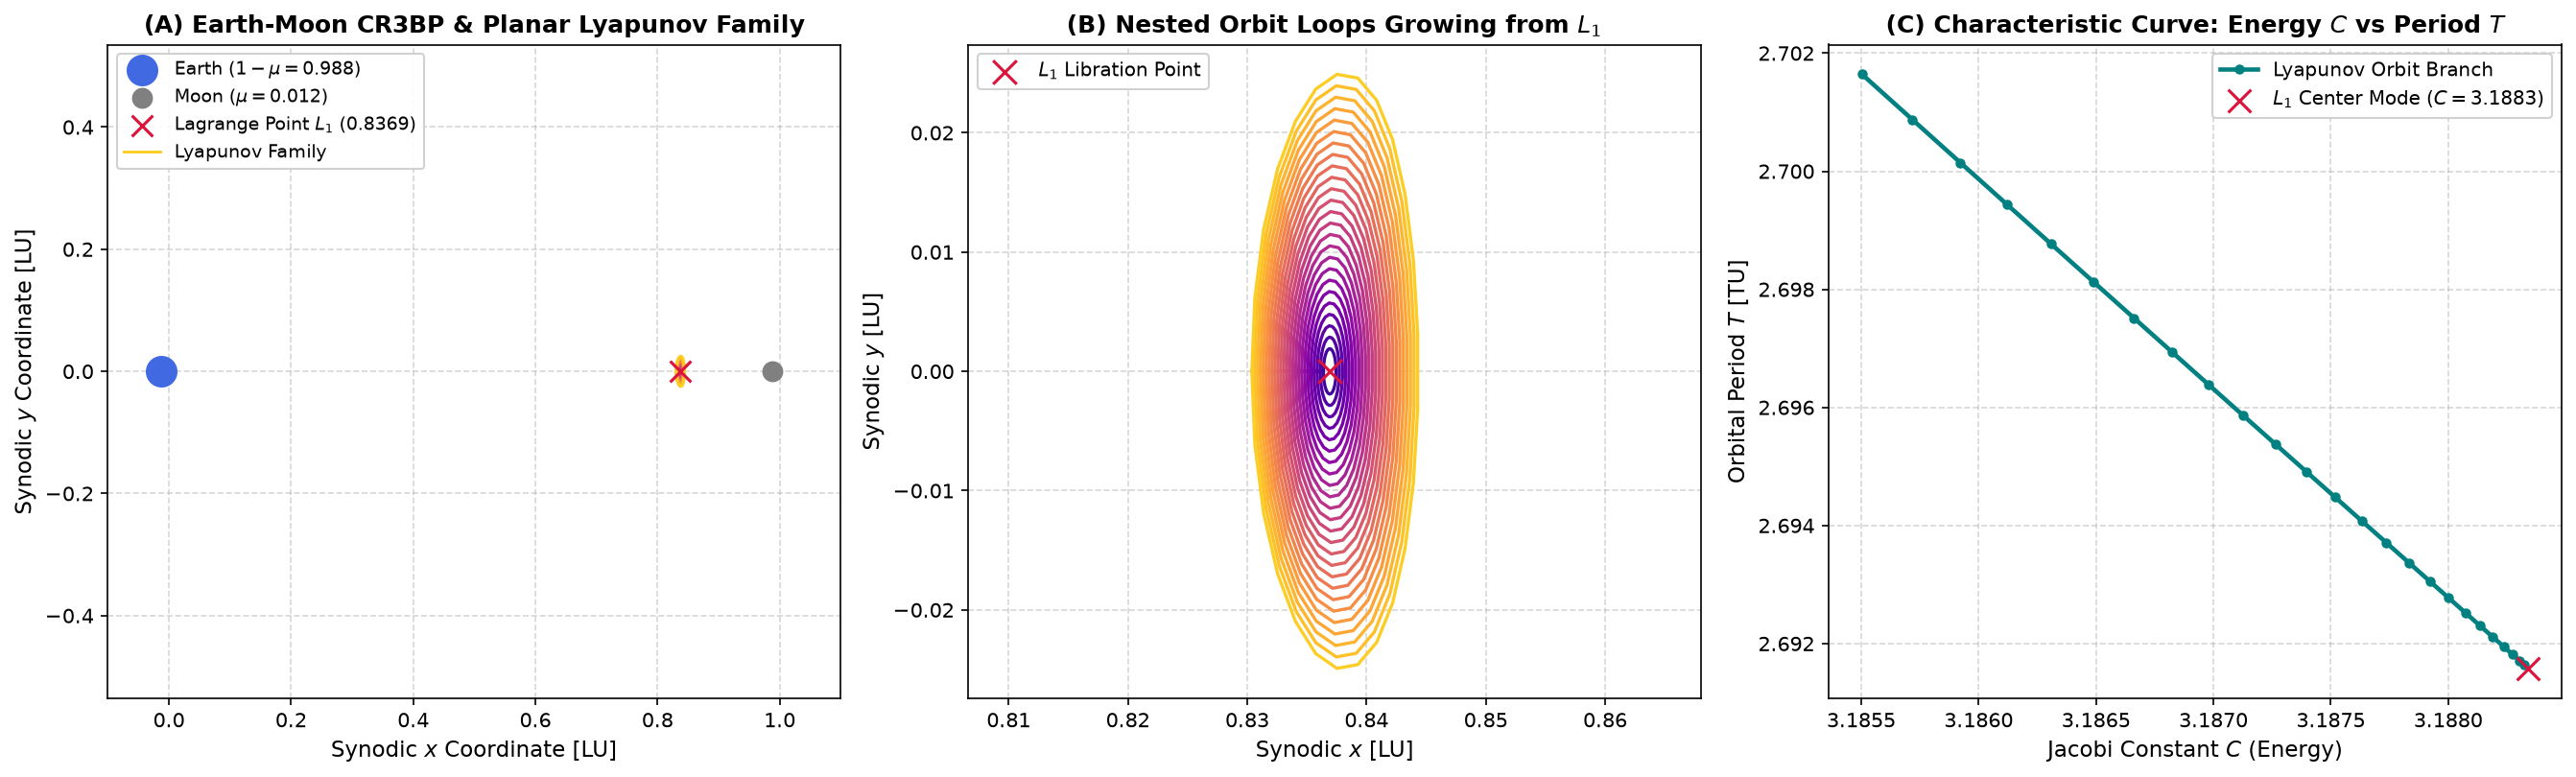

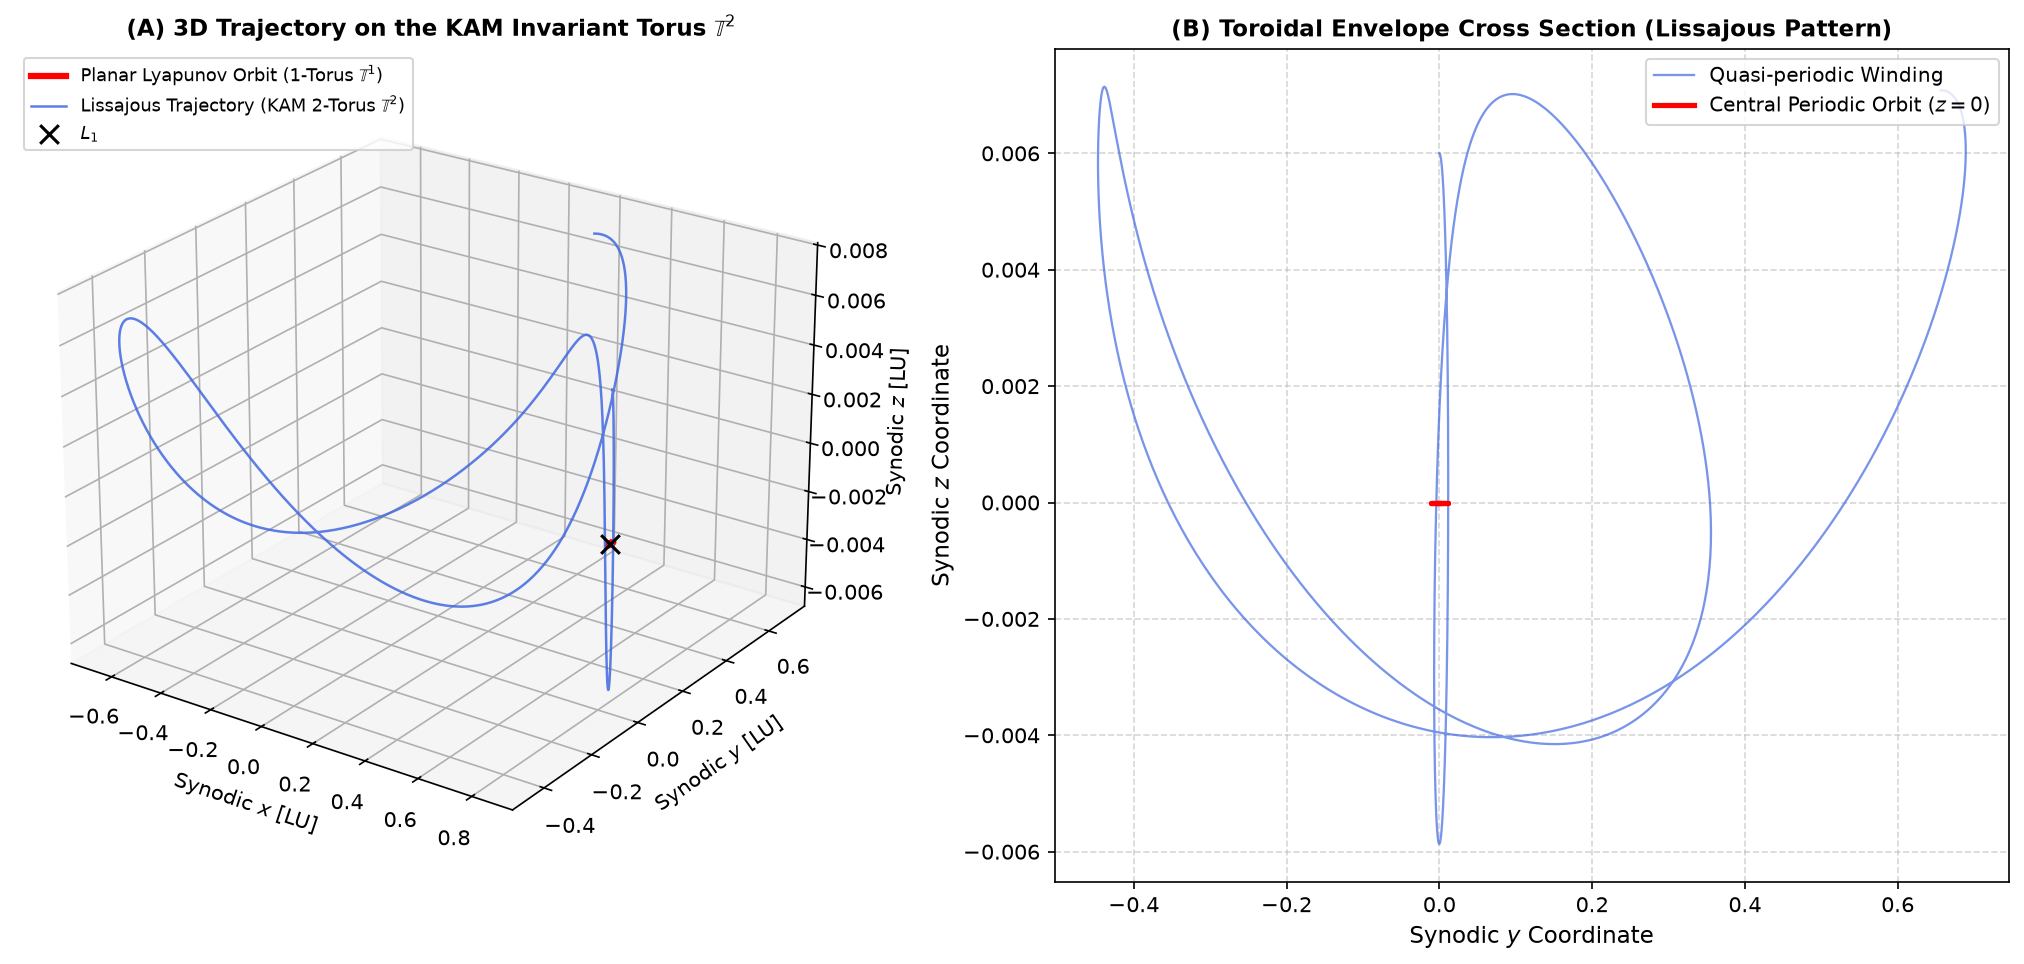

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


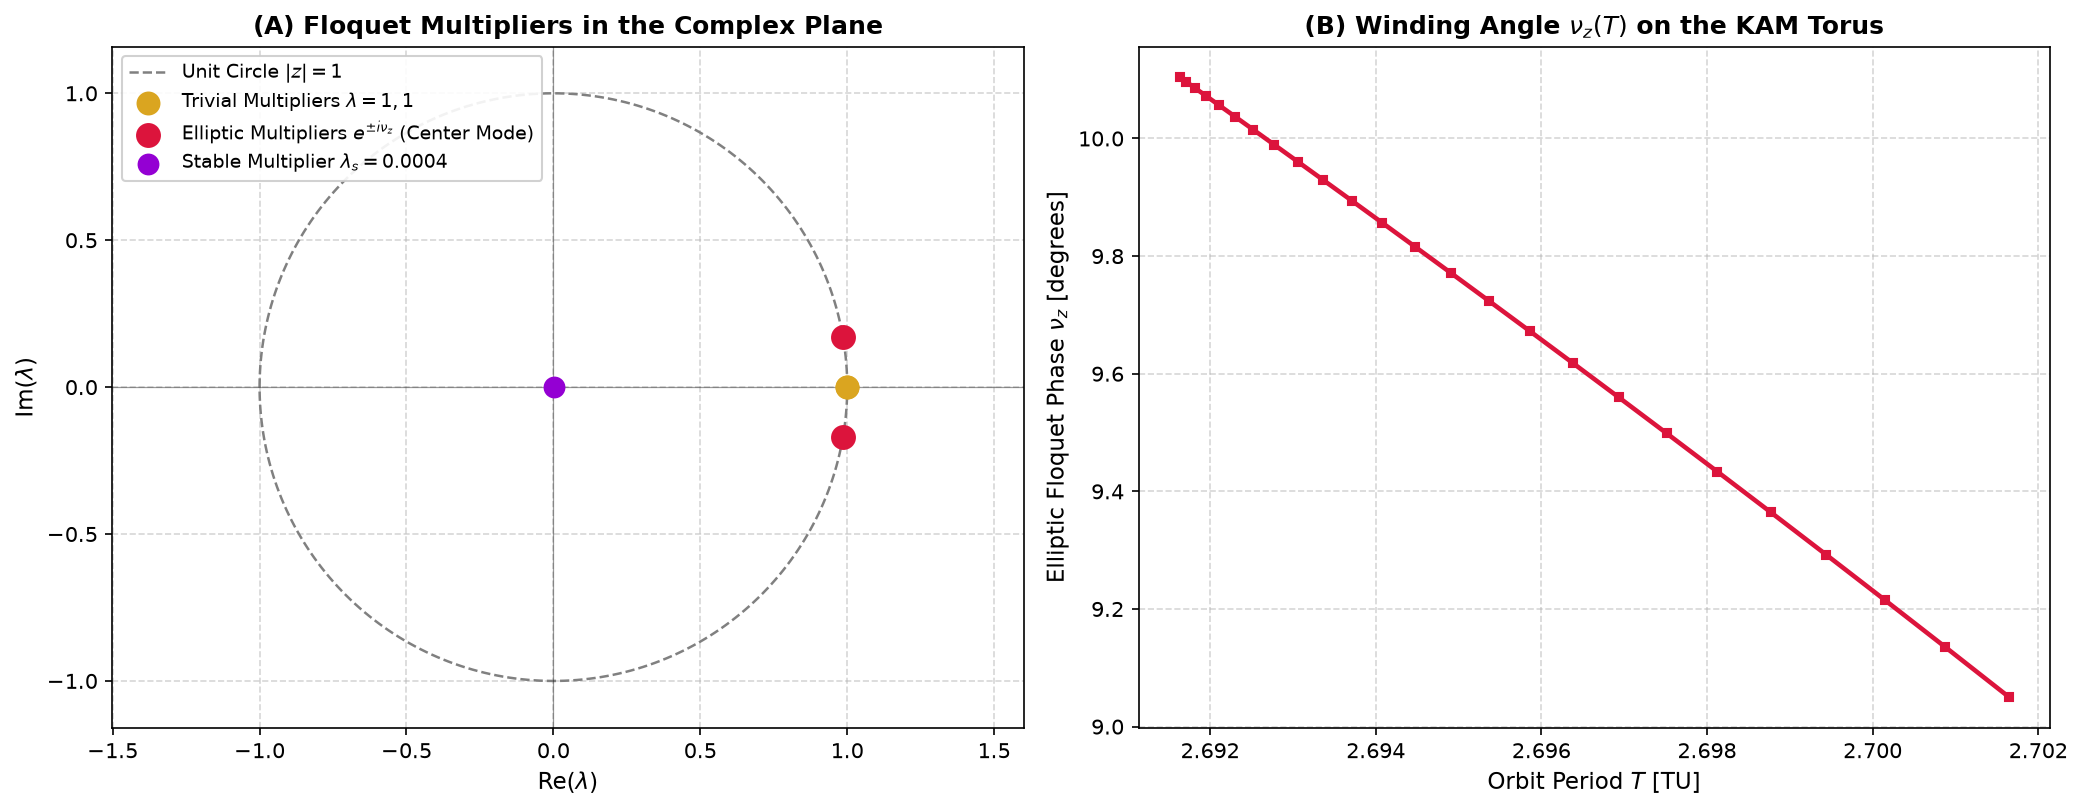

In [8]:
# =============================================================================
# Figure 1: 3-Panel Overview of the Planar Lyapunov Family in CR3BP
# =============================================================================
fig = plt.figure(figsize=(18, 5.5), dpi=150)

# Subplot 1: Synodic (x, y) Global Configuration Space
ax1 = fig.add_subplot(1, 3, 1)
x_earth = -MU
x_moon = 1.0 - MU

ax1.scatter(
    [x_earth], [0], color="royalblue", s=220, zorder=6, label=rf"Earth ($1-\mu={1 - MU:.3f}$)"
)
ax1.scatter([x_moon], [0], color="gray", s=90, zorder=6, label=rf"Moon ($\mu={MU:.3f}$)")
ax1.scatter(
    [x_l1],
    [0],
    color="crimson",
    s=110,
    marker="x",
    zorder=7,
    label=f"Lagrange Point $L_1$ ({x_l1:.4f})",
)

cmap = plt.cm.plasma(np.linspace(0.1, 0.9, len(family["orbits"])))
for i, orb in enumerate(family["orbits"]):
    orb_closed = np.vstack([orb, orb[0]])
    ax1.plot(
        orb_closed[:, 0],
        orb_closed[:, 1],
        color=cmap[i],
        linewidth=1.4,
        label="Lyapunov Family" if i == len(family["orbits"]) - 1 else "",
    )

ax1.set_xlabel("Synodic $x$ Coordinate [LU]", fontsize=11)
ax1.set_ylabel("Synodic $y$ Coordinate [LU]", fontsize=11)
ax1.set_title("(A) Earth-Moon CR3BP & Planar Lyapunov Family", fontsize=12, weight="bold")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.axis("equal")
ax1.set_xlim(-0.1, 1.1)
ax1.legend(loc="upper left", framealpha=0.9, fontsize=9)

# Subplot 2: Zoomed-in Libration Region around L1
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(
    [x_l1], [0], color="crimson", s=140, marker="x", zorder=7, label="$L_1$ Libration Point"
)
for i, orb in enumerate(family["orbits"]):
    orb_closed = np.vstack([orb, orb[0]])
    ax2.plot(orb_closed[:, 0], orb_closed[:, 1], color=cmap[i], linewidth=1.6)

ax2.set_xlabel("Synodic $x$ [LU]", fontsize=11)
ax2.set_ylabel("Synodic $y$ [LU]", fontsize=11)
ax2.set_title("(B) Nested Orbit Loops Growing from $L_1$", fontsize=12, weight="bold")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.axis("equal")
ax2.legend(loc="upper left", framealpha=0.9, fontsize=9.5)

# Subplot 3: Characteristic Continuation Curve (Energy C vs Period T)
ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(
    family["C"],
    family["T"],
    color="teal",
    linewidth=2.2,
    marker="o",
    markersize=4,
    label="Lyapunov Orbit Branch",
)
ax3.scatter(
    [c_l1],
    [T0],
    color="crimson",
    s=130,
    marker="x",
    zorder=6,
    label=f"$L_1$ Center Mode ($C={c_l1:.4f}$)",
)
ax3.set_xlabel("Jacobi Constant $C$ (Energy)", fontsize=11)
ax3.set_ylabel("Orbital Period $T$ [TU]", fontsize=11)
ax3.set_title("(C) Characteristic Curve: Energy $C$ vs Period $T$", fontsize=12, weight="bold")
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend(loc="upper right", framealpha=0.9, fontsize=9.5)

plt.tight_layout()
plt.show()

# =============================================================================
# Figure 2: 3D Visualization of the KAM Invariant Torus (Lissajous Orbit)
# =============================================================================
fig_3d = plt.figure(figsize=(14, 6.5), dpi=150)

# Subplot 1: 3D Spatial Trajectory (x, y, z)
ax_3d = fig_3d.add_subplot(1, 2, 1, projection="3d")
# Plot planar Lyapunov orbit (1-torus T^1)
orb_ref = np.vstack([target_sol.u_mesh, target_sol.u_mesh[0]])
ax_3d.plot(
    orb_ref[:, 0],
    orb_ref[:, 1],
    orb_ref[:, 2],
    color="red",
    linewidth=3.0,
    label="Planar Lyapunov Orbit (1-Torus $\\mathbb{T}^1$)",
)
# Plot 3D quasi-periodic Lissajous trajectory (2-torus T^2)
ax_3d.plot(
    sol_lissajous.y[0],
    sol_lissajous.y[1],
    sol_lissajous.y[2],
    color="royalblue",
    linewidth=1.2,
    alpha=0.85,
    label="Lissajous Trajectory (KAM 2-Torus $\\mathbb{T}^2$)",
)
ax_3d.scatter([x_l1], [0], [0], color="black", s=80, marker="x", label="$L_1$")

ax_3d.set_xlabel("Synodic $x$ [LU]", fontsize=10)
ax_3d.set_ylabel("Synodic $y$ [LU]", fontsize=10)
ax_3d.set_zlabel("Synodic $z$ [LU]", fontsize=10)
ax_3d.set_title(
    "(A) 3D Trajectory on the KAM Invariant Torus $\\mathbb{T}^2$", fontsize=11, weight="bold"
)
ax_3d.legend(loc="upper left", fontsize=8.5)
ax_3d.view_init(elev=24, azim=-55)

# Subplot 2: Out-of-Plane Cross Section (y vs z) - Toroidal Envelope
ax_env = fig_3d.add_subplot(1, 2, 2)
ax_env.plot(
    sol_lissajous.y[1],
    sol_lissajous.y[2],
    color="royalblue",
    alpha=0.7,
    linewidth=1.1,
    label="Quasi-periodic Winding",
)
ax_env.plot(
    orb_ref[:, 1], orb_ref[:, 2], color="red", linewidth=2.5, label="Central Periodic Orbit ($z=0$)"
)
ax_env.set_xlabel("Synodic $y$ Coordinate", fontsize=11)
ax_env.set_ylabel("Synodic $z$ Coordinate", fontsize=11)
ax_env.set_title(
    "(B) Toroidal Envelope Cross Section (Lissajous Pattern)", fontsize=11, weight="bold"
)
ax_env.grid(True, linestyle="--", alpha=0.5)
ax_env.legend(loc="upper right", fontsize=9.5)

plt.tight_layout()
plt.show()

# =============================================================================
# Figure 3: Symplectic Floquet Multiplier Spectrum & Complex Unit Circle
# =============================================================================
fig_flq, (ax_circ, ax_phase) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=150)

# Complex Plane: Unit Circle and Floquet Multipliers
theta_circ = np.linspace(0, 2 * np.pi, 300)
ax_circ.plot(
    np.cos(theta_circ),
    np.sin(theta_circ),
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label="Unit Circle $|z|=1$",
)
ax_circ.axhline(0, color="black", linewidth=0.6, alpha=0.4)
ax_circ.axvline(0, color="black", linewidth=0.6, alpha=0.4)

# Plot multipliers of the sample orbit
m_sample = mults_cond
ax_circ.scatter(
    [m_sample[1].real, m_sample[4].real],
    [m_sample[1].imag, m_sample[4].imag],
    color="goldenrod",
    s=110,
    zorder=6,
    label="Trivial Multipliers $\\lambda=1, 1$",
)
ax_circ.scatter(
    [m_sample[2].real, m_sample[3].real],
    [m_sample[2].imag, m_sample[3].imag],
    color="crimson",
    s=120,
    zorder=7,
    label="Elliptic Multipliers $e^{\\pm i \\nu_z}$ (Center Mode)",
)
ax_circ.scatter(
    [m_sample[5].real],
    [m_sample[5].imag],
    color="darkviolet",
    s=90,
    zorder=6,
    label=f"Stable Multiplier $\\lambda_s={m_sample[5].real:.4f}$",
)

ax_circ.set_xlabel("$\\mathrm{Re}(\\lambda)$", fontsize=11)
ax_circ.set_ylabel("$\\mathrm{Im}(\\lambda)$", fontsize=11)
ax_circ.set_title("(A) Floquet Multipliers in the Complex Plane", fontsize=12, weight="bold")
ax_circ.axis("equal")
ax_circ.set_xlim(-1.3, 1.4)
ax_circ.set_ylim(-1.3, 1.3)
ax_circ.grid(True, linestyle="--", alpha=0.5)
ax_circ.legend(loc="upper left", fontsize=9, framealpha=0.9)

# Subplot 2: Evolution of Elliptic Phase Angle nu_z along the Family
nu_z_vals = [
    float(np.angle([m for m in m_list if abs(abs(m) - 1.0) < 1e-3 and m.imag > 1e-4][0]))
    for m_list in family["multipliers"]
]

ax_phase.plot(
    family["T"], np.degrees(nu_z_vals), color="crimson", linewidth=2.2, marker="s", markersize=4
)
ax_phase.set_xlabel("Orbit Period $T$ [TU]", fontsize=11)
ax_phase.set_ylabel("Elliptic Floquet Phase $\\nu_z$ [degrees]", fontsize=11)
ax_phase.set_title("(B) Winding Angle $\\nu_z(T)$ on the KAM Torus", fontsize=12, weight="bold")
ax_phase.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 8. Summary & Astrodynamic Takeaways

In this demo, we successfully integrated high-order collocation BVP methods, symplectic continuation, and KAM theory:

| Concept / Structure | Mathematical Formulation | Role in Celestial Mechanics & Space Missions |
|---|---|---|
| **$L_1$ Libration Point** | $\nabla \Omega = \mathbf{0}$, Saddle $\times$ Center $\times$ Center | Gateway equilibrium between Earth and Moon |
| **Planar Lyapunov Orbit** | Invariant 1-Torus $\mathbb{T}^1$, period $T$ | Periodic periodic backbone of the center manifold |
| **Lyapunov Center Theorem** | $\lim_{\varepsilon \to 0} T = 2\pi / \omega_p$ | Rigorous existence of periodic orbit families |
| **Gauss Collocation BVP** | 8th-order accuracy, de Boor-Swartz | Superconvergent, robust periodic orbit solving |
| **Pseudo-Arclength Continuation** | Bordered system on $(\mathbf{u}, T)$ manifold | Seamless tracing along the continuous energy manifold |
| **Monodromy Matrix $M$** | $M^T J_{\text{sym}} M = J_{\text{sym}}$ | Symplectic reciprocal pairing: $\lambda_u \cdot \lambda_s = 1$ |
| **Elliptic Multipliers $e^{\pm i \nu}$** | $|\lambda| \equiv 1.000000$ on unit circle | Linear generator of the transverse 2D center manifold |
| **KAM Torus $\mathbb{T}^2$ (Lissajous)** | Non-resonant frequencies $\omega_1, \omega_2$ | **Real flight orbits for JWST, SOHO, DSCOVR, WMAP** |
| **Station-Keeping Fuel Savings** | Trajectories naturally bounded on KAM tori | Minimal thruster maintenance ($\Delta V < 2\text{ m/s/yr}$) |

### Next Steps:
- Explore 3D **Halo Orbit Families** bifurcating from the planar Lyapunov family at finite amplitude.
- Investigate **invariant manifold tubes** ($W^u, W^s$) for low-energy ballistic lunar and interplanetary transfer trajectories.